In [1]:
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
from amstools import *

In [3]:
from ase.build import bulk

In [4]:
from ase.calculators.emt import EMT

In [5]:
element="Cu"

Create initial structure

In [6]:
structure = bulk(element,"fcc")

structure

Atoms(symbols='Cu', pbc=True, cell=[[0.0, 1.805, 1.805], [1.805, 0.0, 1.805], [1.805, 1.805, 0.0]])

Create ASE-compatible calculator

In [7]:
calc = EMT()

Most frequent scenario for the atomic properties calculation is to optimize structure in one step and pass it to the next one to form a **pipeline**. In **pipeline**, structure is passed from one step to following one.  These **steps** are just wrapper around **properties calculators**.

Some steps would modify the structure, some would use the structure for calculations, but remain structure unchanged.  Below is the list of the steps and corresponding properties calculators:

Steps that modify the structure:
 -  IsoOptimizer()
 -  SpecialOptimizer(optimize_atoms_only=True)
 -  StepwiseOptimizer()
 -  MurnaghanCalculator()
 
Steps that don't modify the structure:
 -  StaticCalculator
 -  ElasticMatrixCalculator
 -  DefectFormationCalculator
 -  InterstitialFormationCalculator
 -  NearestNeighboursExpansionCalculator
 -  PhonopyCalculator
 -  StackingFaultCalculator
 -  SurfaceEnergyCalculator
 -  SurfaceDecohesionCalculator
 -  ThermodynamicQHACalculator
 -  TransformationPathCalculator
 

Here we create simple pipeline, start from optimization, then E-NN distance curve, E-V curve (Murnaghan), Elastic matrix, phonons and two transformation paths with different type ("orthogonal" and "tetragonal").


You can create a step with all defaults settings, but also specify the desired ones.  For example, **NearestNeighboursExpansionCalculator** has such parameters as *nn_distance_range* and *nn_distance_step*. These parameters we could pass directly as arguments to the step, i.e.
```python
NearestNeighboursExpansionCalculator(nn_distance_range=(2, 5), nn_distance_step=0.05)
```


In [8]:
from amstools import *

In [9]:

pipeline = (
    StepwiseOptimizer() + 
    NearestNeighboursExpansionCalculator(nn_distance_range=(2, 5), nn_distance_step=0.05) + 
    MurnaghanCalculator(num_of_point=15, volume_range=0.1, fit_order=5) + 
    SurfaceEnergyCalculator(surface_orientation='111', surface_name='X121_Y-101_Z1-11_6at') + 
    ElasticMatrixCalculator(eps_range=0.015, num_of_point=11) + 
    PhonopyCalculator() + 
    TransformationPathCalculator(transformation_type="tetragonal") + 
    TransformationPathCalculator(transformation_type="orthogonal")
)


Running the pipeline with provided initial structure and calculator

In [10]:
pipeline.run(structure, calc, verbose=True)

2026-03-01 20:31:05,779 - root - INFO - =======================
2026-03-01 20:31:05,780 - root - INFO - Step: optimization
Processing: optimized_structure (1 atom(s)): 100%|██████████| 1/1 [00:00<00:00, 11.18it/s]
2026-03-01 20:31:05,891 - root - INFO - Step status: finished
2026-03-01 20:31:05,892 - root - INFO - =======================
2026-03-01 20:31:05,892 - root - INFO - =======================
2026-03-01 20:31:05,892 - root - INFO - Step: energy_nn_distance
Processing: nndist_4_9500 (1 atom(s)): 100%|██████████| 60/60 [00:00<00:00, 317.73it/s]
2026-03-01 20:31:06,090 - root - INFO - Job is done
2026-03-01 20:31:06,090 - root - INFO - Step status: finished
2026-03-01 20:31:06,090 - root - INFO - =======================
2026-03-01 20:31:06,091 - root - INFO - =======================
2026-03-01 20:31:06,091 - root - INFO - Step: murnaghan
Processing: strain_1_1 (1 atom(s)): 100%|██████████| 15/15 [00:00<00:00, 183.70it/s]     
2026-03-01 20:31:06,175 - root - INFO - Job is done
202

Reading /Users/lysogy36/micromamba/envs/grace/lib/python3.11/site-packages/amstools/resources/data/structures/Surfaces/fcc/111/fcc_111surf_X121_Y-101_Z1-11_6at.cfg


Processing: SURFACE___atomic (6 atom(s)):   0%|          | 0/2 [00:00<?, ?it/s]

      Step     Time          Energy          fmax
FIRE:    0 20:31:06        4.541052        1.096782
FIRE:    1 20:31:06        4.492864        1.099886
FIRE:    2 20:31:06        4.396012        1.104202
FIRE:    3 20:31:06        4.250061        1.105507
FIRE:    4 20:31:06        4.055821        1.096379
FIRE:    5 20:31:06        3.817498        1.065303
FIRE:    6 20:31:06        3.545717        0.997965
FIRE:    7 20:31:06        3.262645        0.859635
FIRE:    8 20:31:06        2.987677        0.590570
FIRE:    9 20:31:06        2.830835        0.168385
FIRE:   10 20:31:06        2.874440        0.414603
FIRE:   11 20:31:06        2.871440        0.402354
FIRE:   12 20:31:06        2.865790        0.378391
FIRE:   13 20:31:06        2.858145        0.343741
FIRE:   14 20:31:06        2.849373        0.299846
FIRE:   15 20:31:06        2.840445        0.248457
FIRE:   16 20:31:06        2.832314        0.191511
FIRE:   17 20:31:06        2.825810        0.131013
FIRE:   18 20:

Processing: SURFACE___atomic (6 atom(s)): 100%|██████████| 2/2 [00:00<00:00, 53.65it/s]
2026-03-01 20:31:06,234 - root - INFO - Job is done
2026-03-01 20:31:06,234 - root - INFO - Step status: finished
2026-03-01 20:31:06,234 - root - INFO - =======================
2026-03-01 20:31:06,235 - root - INFO - =======================
2026-03-01 20:31:06,235 - root - INFO - Step: elastic_matrix
Processing: s_e_0 (1 atom(s)):   0%|          | 0/31 [00:00<?, ?it/s]

...

Processing: s_23_e_0_01200 (1 atom(s)):  55%|█████▍    | 17/31 [00:00<00:00, 163.94it/s]

      Step     Time          Energy          fmax
BFGS:    0 20:31:06       -0.001384        0.000000


Processing: s_23_e_0_01500 (1 atom(s)):  55%|█████▍    | 17/31 [00:00<00:00, 163.94it/s]

      Step     Time          Energy          fmax
BFGS:    0 20:31:06        0.001824        0.000000


Processing: s_23_e_0_01500 (1 atom(s)): 100%|██████████| 31/31 [00:00<00:00, 162.80it/s]
2026-03-01 20:31:06,441 - root - INFO - Job is done
2026-03-01 20:31:06,441 - root - INFO - Step status: finished
2026-03-01 20:31:06,441 - root - INFO - =======================
2026-03-01 20:31:06,442 - root - INFO - =======================
2026-03-01 20:31:06,442 - root - INFO - Step: phonons
Processing: supercell_phonon_0 (64 atom(s)): 100%|██████████| 1/1 [00:00<00:00, 94.22it/s]
2026-03-01 20:31:08,196 - root - INFO - Job is done
2026-03-01 20:31:08,197 - root - INFO - Step status: finished
2026-03-01 20:31:08,197 - root - INFO - =======================
2026-03-01 20:31:08,197 - root - INFO - =======================
2026-03-01 20:31:08,197 - root - INFO - Step: transformation_path
Processing: tp_2_00000 (2 atom(s)): 100%|██████████| 50/50 [00:00<00:00, 296.61it/s]
2026-03-01 20:31:08,377 - root - INFO - Job is done
2026-03-01 20:31:08,377 - root - INFO - Step status: finished
2026-03-01 20:31:

In [11]:
pipeline

Pipeline(status='finished', path=None)
  [0] optimization: StepwiseOptimizer(name='optimization', status='finished', fmax=0.005, max_steps=500, dEmax=0.001, relative_volume_change_tolerance=0.01, max_restart=5, optimizer='BFGS')
  [1] energy_nn_distance: NearestNeighboursExpansionCalculator(name='energy_nn_distance', status='finished', num_of_point=None, nn_distance_range=(2, 5), nn_distance_step=0.05, nn_distance_list=None, fix_kmesh=False, return_min_structure=False)
  [2] murnaghan: MurnaghanCalculator(name='murnaghan', status='finished', num_of_point=15, volume_range=0.1, fit_order=5, optimize_deformed_structure=False, optimizer=<class 'ase.optimize.bfgs.BFGS'>, fmax=0.005, optimizer_kwargs={})
  [3] surface_energy: SurfaceEnergyCalculator(name='surface_energy', status='finished', surface_orientation='111', surface_name='X121_Y-101_Z1-11_6at', optimizer=<class 'ase.optimize.fire.FIRE'>, fmax=0.01, optimizer_kwargs={}, fix_symmetry=True)
  [4] elastic_matrix: ElasticMatrixCalculator

In [12]:
# pipeline.plot()

One could also give names to the steps and specify them as dictionary (since  Python 3.6+, dictionaries are ordered, for earlier versions you should use *OrderedDict* from *collections* module `from collections import OrderedDict`)

In [13]:
from amstools import PhonopyCalculator
from amstools import ElasticMatrixCalculator
from amstools import NearestNeighboursExpansionCalculator
from amstools import StepwiseOptimizer
pipeline = Pipeline(steps={
    "optimization":StepwiseOptimizer(),
    "e_nn_dist":NearestNeighboursExpansionCalculator(
        nn_distance_range=(2, 5), nn_distance_step=0.05),
    "murnaghan":MurnaghanCalculator(num_of_point=15, volume_range=0.1, fit_order=5),
    "elastic":ElasticMatrixCalculator(eps_range=0.015, num_of_point=11),
    "phonon":PhonopyCalculator(),
    "tp_tetrag":TransformationPathCalculator(transformation_type="tetragonal"),
    "tp_orthogonal":TransformationPathCalculator(transformation_type="orthogonal")    
})

In [14]:
pipeline

Pipeline(status='created', path=None)
  [0] optimization: StepwiseOptimizer(name=None, status='created', fmax=0.005, max_steps=500, dEmax=0.001, relative_volume_change_tolerance=0.01, max_restart=5, optimizer='BFGS')
  [1] e_nn_dist: NearestNeighboursExpansionCalculator(name=None, status='created', num_of_point=None, nn_distance_range=(2, 5), nn_distance_step=0.05, nn_distance_list=None, fix_kmesh=False, return_min_structure=False)
  [2] murnaghan: MurnaghanCalculator(name=None, status='created', num_of_point=15, volume_range=0.1, fit_order=5, optimize_deformed_structure=False, optimizer=<class 'ase.optimize.bfgs.BFGS'>, fmax=0.005, optimizer_kwargs={})
  [3] elastic: ElasticMatrixCalculator(name=None, status='created', num_of_point=11, eps_range=0.015, sqrt_eta=True, fit_order=2, optimize_deformed_structure=True, optimizer=<class 'ase.optimize.bfgs.BFGS'>, fmax=0.005, optimizer_kwargs={}, ignore_symmetry=False)
  [4] phonon: PhonopyCalculator(name=None, status='created', interaction_r

Running the pipeline with provided initial structure and calculator

In [15]:
pipeline.run(structure, calc, verbose=True)

2026-03-01 20:31:08,579 - root - INFO - =======================
2026-03-01 20:31:08,580 - root - INFO - Step: optimization
Processing: optimized_structure (1 atom(s)): 100%|██████████| 1/1 [00:00<00:00, 43.96it/s]
2026-03-01 20:31:08,604 - root - INFO - Step status: finished
2026-03-01 20:31:08,604 - root - INFO - =======================
2026-03-01 20:31:08,605 - root - INFO - =======================
2026-03-01 20:31:08,605 - root - INFO - Step: e_nn_dist
Processing: nndist_4_9500 (1 atom(s)): 100%|██████████| 60/60 [00:00<00:00, 318.50it/s]
2026-03-01 20:31:08,799 - root - INFO - Job is done
2026-03-01 20:31:08,799 - root - INFO - Step status: finished
2026-03-01 20:31:08,799 - root - INFO - =======================
2026-03-01 20:31:08,799 - root - INFO - =======================
2026-03-01 20:31:08,799 - root - INFO - Step: murnaghan
Processing: strain_1_1 (1 atom(s)): 100%|██████████| 15/15 [00:00<00:00, 187.55it/s]     
2026-03-01 20:31:08,881 - root - INFO - Job is done
2026-03-01 2

      Step     Time          Energy          fmax
BFGS:    0 20:31:08       -0.007036        0.000000


Processing: s_01_e_m0_01500 (1 atom(s)):   0%|          | 0/31 [00:00<?, ?it/s]

      Step     Time          Energy          fmax
BFGS:    0 20:31:08        0.003441        0.000000


Processing: s_01_e_m0_01200 (1 atom(s)):   0%|          | 0/31 [00:00<?, ?it/s]

...

Processing: s_23_e_0_01200 (1 atom(s)):  55%|█████▍    | 17/31 [00:00<00:00, 167.66it/s]

      Step     Time          Energy          fmax
BFGS:    0 20:31:09       -0.001384        0.000000


Processing: s_23_e_0_01500 (1 atom(s)):  55%|█████▍    | 17/31 [00:00<00:00, 167.66it/s]

      Step     Time          Energy          fmax
BFGS:    0 20:31:09        0.001824        0.000000


Processing: s_23_e_0_01500 (1 atom(s)): 100%|██████████| 31/31 [00:00<00:00, 168.22it/s]
2026-03-01 20:31:09,081 - root - INFO - Job is done
2026-03-01 20:31:09,082 - root - INFO - Step status: finished
2026-03-01 20:31:09,082 - root - INFO - =======================
2026-03-01 20:31:09,082 - root - INFO - =======================
2026-03-01 20:31:09,082 - root - INFO - Step: phonon
Processing: supercell_phonon_0 (64 atom(s)): 100%|██████████| 1/1 [00:00<00:00, 93.72it/s]
2026-03-01 20:31:11,014 - root - INFO - Job is done
2026-03-01 20:31:11,015 - root - INFO - Step status: finished
2026-03-01 20:31:11,015 - root - INFO - =======================
2026-03-01 20:31:11,015 - root - INFO - =======================
2026-03-01 20:31:11,016 - root - INFO - Step: tp_tetrag
Processing: tp_2_00000 (2 atom(s)): 100%|██████████| 50/50 [00:00<00:00, 260.85it/s]
2026-03-01 20:31:11,220 - root - INFO - Job is done
2026-03-01 20:31:11,232 - root - INFO - Step status: finished
2026-03-01 20:31:11,234 - ro

Here are the pipeline steps:

In [16]:
pipeline.steps

{'optimization': StepwiseOptimizer(name=None, status='finished', fmax=0.005, max_steps=500, dEmax=0.001, relative_volume_change_tolerance=0.01, max_restart=5, optimizer='BFGS'),
 'e_nn_dist': NearestNeighboursExpansionCalculator(name=None, status='finished', num_of_point=None, nn_distance_range=(2, 5), nn_distance_step=0.05, nn_distance_list=None, fix_kmesh=False, return_min_structure=False),
 'murnaghan': MurnaghanCalculator(name=None, status='finished', num_of_point=15, volume_range=0.1, fit_order=5, optimize_deformed_structure=False, optimizer=<class 'ase.optimize.bfgs.BFGS'>, fmax=0.005, optimizer_kwargs={}),
 'elastic': ElasticMatrixCalculator(name=None, status='finished', num_of_point=11, eps_range=0.015, sqrt_eta=True, fit_order=2, optimize_deformed_structure=True, optimizer=<class 'ase.optimize.bfgs.BFGS'>, fmax=0.005, optimizer_kwargs={}, ignore_symmetry=False),
 'phonon': PhonopyCalculator(name=None, status='finished', interaction_range=10.0, displacement=0.01, supercell_rang

Now, you can access the steps of the pipeline by 

In [17]:
pipeline["murnaghan"]

MurnaghanCalculator(name=None, status='finished', num_of_point=15, volume_range=0.1, fit_order=5, optimize_deformed_structure=False, optimizer=<class 'ase.optimize.bfgs.BFGS'>, fmax=0.005, optimizer_kwargs={})

In [18]:
pipeline["murnaghan"].value

OrderedDict([('volume',
              array([10.40657771, 10.57176148, 10.73694526, 10.90212903, 11.0673128 ,
                     11.23249658, 11.39768035, 11.56286412, 11.7280479 , 11.89323167,
                     12.05841544, 12.22359921, 12.38878299, 12.55396676, 12.71915053])),
             ('energy',
              array([ 0.05118334,  0.03470069,  0.02124506,  0.01063244,  0.00267592,
                     -0.00280687, -0.00598974, -0.00703626, -0.00609941, -0.0033217 ,
                      0.00116446,  0.00723636,  0.01478076,  0.02369371,  0.03388057])),
             ('pressure',
              array([ 0.10930185,  0.09043983,  0.072664  ,  0.05602009,  0.04049966,
                      0.02605996,  0.01264238,  0.00018298, -0.01138235, -0.02211588,
                     -0.03207752, -0.04132516, -0.04991546, -0.05790468, -0.06534881])),
             ('equilibrium_energy', np.float64(-0.0070384848577269565)),
             ('equilibrium_volume', np.float64(11.565312361527544)),
 

As was mentioned before, some steps (i.e. AMStoolsFullRelaxationStep or AMStoolsMurnaghanStep) change the structure:

Initial structure:

In [19]:
pipeline["optimization"].structure.cell

Cell([[0.0, 1.805, 1.805], [1.805, 0.0, 1.805], [1.805, 1.805, 0.0]])

Optimized structure:

In [20]:
pipeline["optimization"].get_final_structure().cell

Cell([[7.303783853763874e-18, 1.7947824278463678, 1.7947824278463687], [1.7947824278463687, -6.5333700475588904e-18, 1.7947824278463687], [1.7947824278463687, 1.7947824278463678, 1.0608238060679911e-17]])

The structure is passed to the next step of the pipeline, i.e. optimized structure from "optimization" (AMStoolsFullRelaxationStep) step was passed to the next "e_nn_dist" (AMStoolsNNExpansionStep):

In [21]:
pipeline["e_nn_dist"].basis_ref.cell

Cell([[7.303783853763874e-18, 1.7947824278463678, 1.7947824278463687], [1.7947824278463687, -6.5333700475588904e-18, 1.7947824278463687], [1.7947824278463687, 1.7947824278463678, 1.0608238060679911e-17]])

And then, without any changes to the "murnaghan" step:

In [22]:
pipeline["murnaghan"].basis_ref.cell

Cell([[7.303783853763874e-18, 1.7947824278463678, 1.7947824278463687], [1.7947824278463687, -6.5333700475588904e-18, 1.7947824278463687], [1.7947824278463687, 1.7947824278463678, 1.0608238060679911e-17]])

Where it was modified to newly precised equilibrium volume:

In [23]:
pipeline["murnaghan"].get_final_structure().cell

Cell([[7.304299301266072e-18, 1.7949090904281122, 1.794909090428113], [1.794909090428113, -6.533831124904465e-18, 1.794909090428113], [1.794909090428113, 1.7949090904281122, 1.0608986712326862e-17]])

This equilibrium structure was used for the the rest of the pipeline:

In [24]:
pipeline["elastic"].basis_ref.cell

Cell([[7.304299301266072e-18, 1.7949090904281122, 1.794909090428113], [1.794909090428113, -6.533831124904465e-18, 1.794909090428113], [1.794909090428113, 1.7949090904281122, 1.0608986712326862e-17]])

In [25]:
pipeline["phonon"].basis_ref.cell

Cell([[7.304299301266072e-18, 1.7949090904281122, 1.794909090428113], [1.794909090428113, -6.533831124904465e-18, 1.794909090428113], [1.794909090428113, 1.7949090904281122, 1.0608986712326862e-17]])

One could access the computed properties by `.value` dictionary:

In [26]:
pipeline["elastic"].value["C"]

array([[172.97579413, 115.75487376, 115.75487376,   0.        ,
          0.        ,   0.        ],
       [115.75487376, 172.97579413, 115.75487376,   0.        ,
          0.        ,   0.        ],
       [115.75487376, 115.75487376, 172.97579413,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        ,  90.40739866,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        ,   0.        ,
         90.40739866,   0.        ],
       [  0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,  90.40739866]])

Or use advanced functional of each calculator type:

In [27]:
path = [[[0, 0, 0], [0.5, 0, 0.5], [0.625, 0.25, 0.625],
        [0.375, 0.375, 0.75], [0, 0, 0], [0.5, 0.5, 0.5], [0.5, 0.25, 0.75]]]
labels = ["G", "X", "U", "K", "G", "L", "W"]

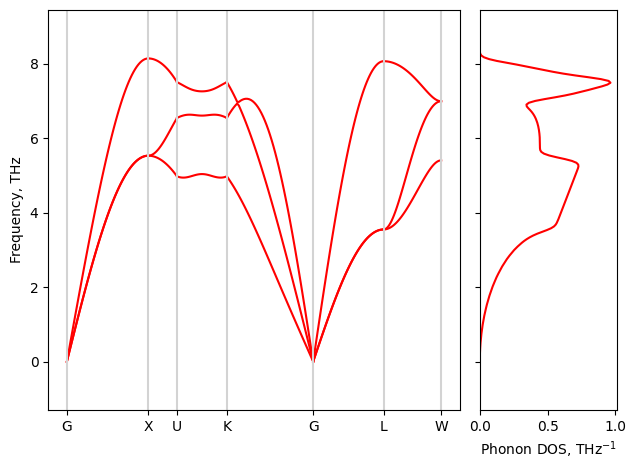

In [28]:
pipeline["phonon"].plot_band_structure_and_dos(path,labels)

Text(0.5, 1.0, 'Transformation path:tetragonal')

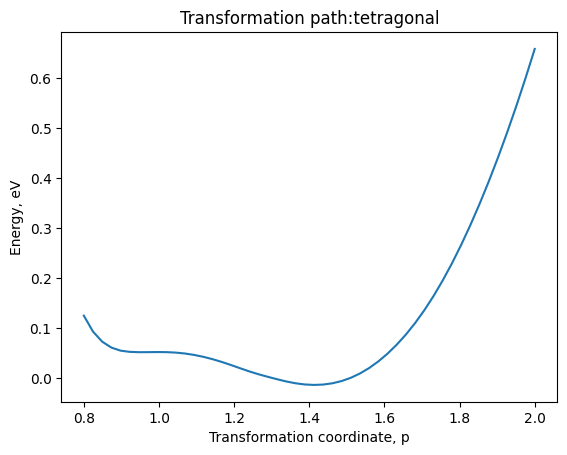

In [29]:
plt.plot(
    pipeline["tp_tetrag"].value["transformation_coordinates"], 
    pipeline["tp_tetrag"].value["energies_0"]
)
plt.xlabel("Transformation coordinate, p")
plt.ylabel("Energy, eV")
plt.title("Transformation path:"+ pipeline["tp_tetrag"].value["transformation_type"])

Or you can call plot whole pipeline

2026-03-01 20:31:11,956 - root - INFO - Plotting step: optimization
2026-03-01 20:31:11,962 - root - INFO - Plotting step: e_nn_dist


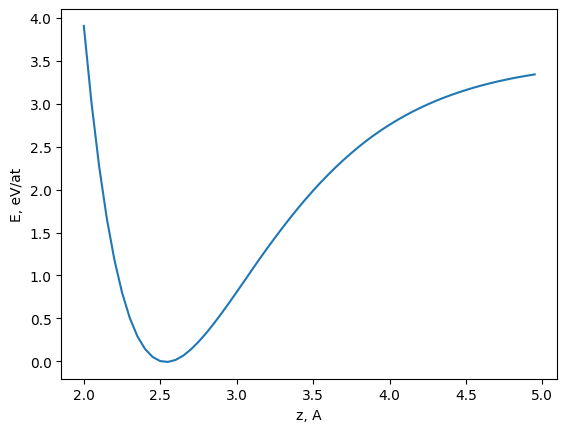

2026-03-01 20:31:12,020 - root - INFO - Plotting step: murnaghan


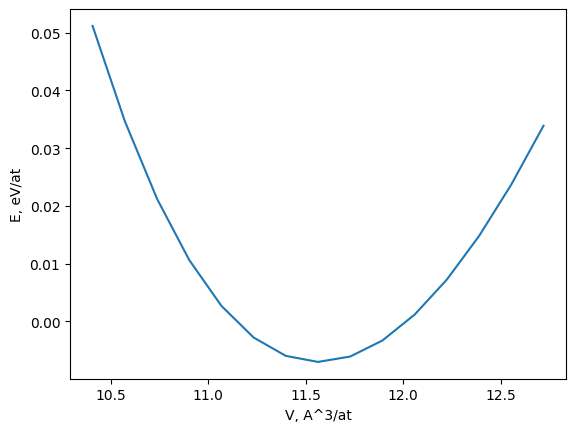

2026-03-01 20:31:12,074 - root - INFO - Plotting step: elastic


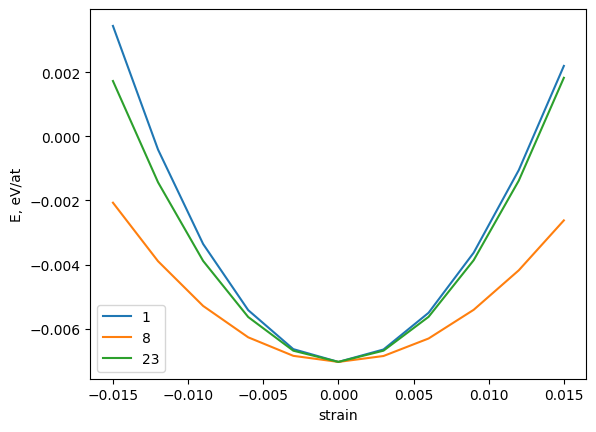

2026-03-01 20:31:12,162 - root - INFO - Plotting step: phonon


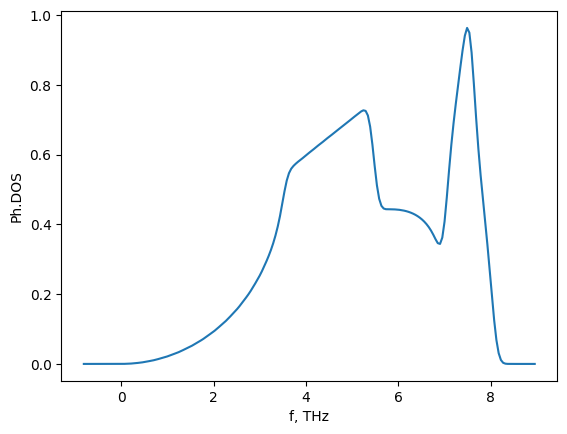

2026-03-01 20:31:12,205 - root - INFO - Plotting step: tp_tetrag


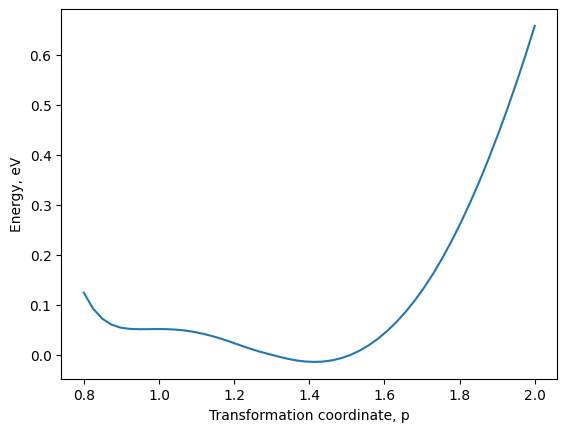

2026-03-01 20:31:12,251 - root - INFO - Plotting step: tp_orthogonal


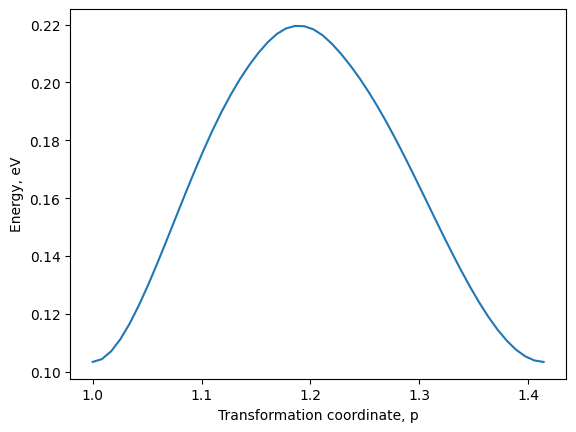

[<Axes: xlabel='z, A', ylabel='E, eV/at'>,
 <Axes: xlabel='V, A^3/at', ylabel='E, eV/at'>,
 <Axes: xlabel='strain', ylabel='E, eV/at'>,
 <Axes: xlabel='f, THz', ylabel='Ph.DOS'>,
 <Axes: xlabel='Transformation coordinate, p', ylabel='Energy, eV'>,
 <Axes: xlabel='Transformation coordinate, p', ylabel='Energy, eV'>]

In [30]:
pipeline.plot()